# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: The Pre-Publish Ethics Review - PES2UG24CS461

### Scenario

You're a junior analyst at **Northwind Retail Insights**. A colleague drafted a set of
charts for tomorrow's regional performance report, and your manager asked you to review
them before they go out. She's blunt about what she wants checked:

1. *"I can't tell what I'm supposed to look at first on any of these charts. There's no
   hierarchy."*
2. *"One of these charts will get someone using a grayscale office printer completely
   lost. Fix that before it ships."*
3. *"I saw a headline chart that made a tiny year-over-year change look like a crisis.
   Check the axis."*
4. *"Someone wrote 'this PROVES our new strategy is working' under a chart. That's not
   what a data label is for."*

You'll work through the same review a real analyst would: fix a hierarchy problem, make
a chart accessible, catch a scale exaggeration, and rewrite an overreaching annotation.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real sales data you'll be working with.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

print(f"Loaded {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

Loaded 8,399 orders, 2009-2012.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## Task 1 — Fix the Missing Hierarchy (Complaint #1)

**Real-world usage:** The manager can't tell what to look at first on the current
chart.

**Why this technique:** Visual hierarchy (size + weight + color) creates an
unmistakable primary -> secondary -> tertiary reading order without needing
instructions.

**TODO:** Build a figure with 3 text elements, using ONLY `fontsize`, `fontweight`, and
`color` to create hierarchy:
1. **Primary:** the region with the highest total profit, in large bold colored text.
2. **Secondary:** one supporting sentence, medium size, muted color.
3. **Tertiary:** a data-source footnote, small, light gray.

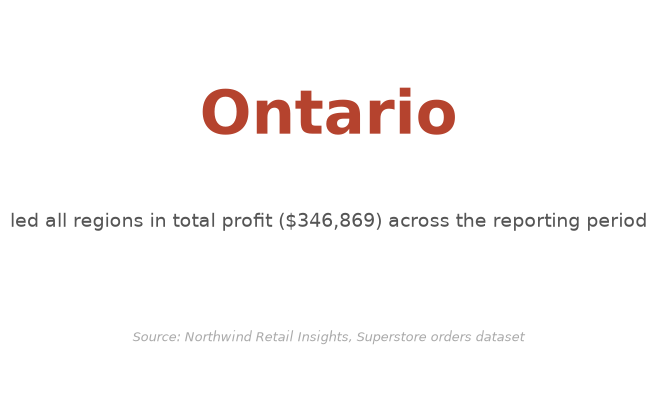

In [4]:
region_totals = sales.groupby("Region")["Profit"].sum().sort_values()
best_region = region_totals.idxmax()
best_value = region_totals.max()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# Primary: large, bold, colored
ax.text(0.5, 0.72, f"{best_region}",
        fontsize=44, fontweight="bold", color="#b5432e",
        ha="center", va="center")

# Secondary: medium, muted
ax.text(0.5, 0.45,
        f"led all regions in total profit (${best_value:,.0f}) across the reporting period",
        fontsize=14, color="#555555", ha="center", va="center")

# Tertiary: small, light gray
ax.text(0.5, 0.15, "Source: Northwind Retail Insights, Superstore orders dataset",
        fontsize=9, color="#aaaaaa", ha="center", va="center", style="italic")

plt.show()

**Reflection:**

_Your answer:_ Eyes land on the big colored region name first, then the medium supporting sentence, then the tiny gray footnote. In 2 seconds a reader walks away knowing which region led on profit.

## Task 2 — Make the Chart Accessible (Complaint #2)

**Real-world usage:** A colorblind or grayscale-printer viewer needs to be able to read
this chart too.

**Why this technique:** Redundant coding (color + pattern/shape) survives both
colorblindness and grayscale printing; color alone does not.

**TODO:**
1. Build a bar chart of total `Sales` by `Product Category`, one color per category.
2. Add a DIFFERENT hatch pattern per bar (`hatch="//"`, `"xx"`, `".."`) on top of the
   color, so the categories stay distinguishable if color is stripped away.
3. Add a legend showing category name.

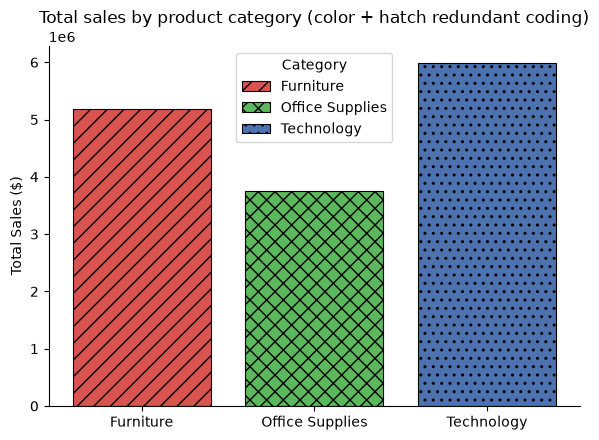

In [5]:
cat_sales = sales.groupby("Product Category")["Sales"].sum()

colors = {"Furniture": "#D9534F", "Office Supplies": "#5cb85c", "Technology": "#4C72B0"}
hatches = {"Furniture": "//", "Office Supplies": "xx", "Technology": ".."}

fig, ax = plt.subplots(figsize=(6, 4.5))
for cat in cat_sales.index:
    ax.bar(cat, cat_sales[cat],
           color=colors.get(cat, "#888"),
           hatch=hatches.get(cat, ""),
           edgecolor="black", linewidth=0.8,
           label=cat)

ax.legend(title="Category")
ax.set_ylabel("Total Sales ($)")
ax.set_title("Total sales by product category (color + hatch redundant coding)")
plt.tight_layout()
plt.show()

**Reflection:**

_Your answer:_ Red-green colorblindness (Furniture vs. Office Supplies become indistinguishable) and grayscale printing (all bars collapse to similar grays). Both fail because color is the sole channel.

## Task 3 — Catch the Axis Exaggeration (Complaint #3)

**Real-world usage:** A headline chart made a small real change look like a crisis.

**Why this technique:** Comparing the SAME data on a zero-baseline axis vs. a truncated
axis reveals exactly how much an axis choice is doing the "storytelling" instead of the
data.

**TODO:**
1. Compute total `Sales` by `Year`.
2. Compute the real percent change between the two most recent years.
3. Plot BOTH a zero-baseline version and a truncated-axis version, side by side, each
   titled with the real percent change.

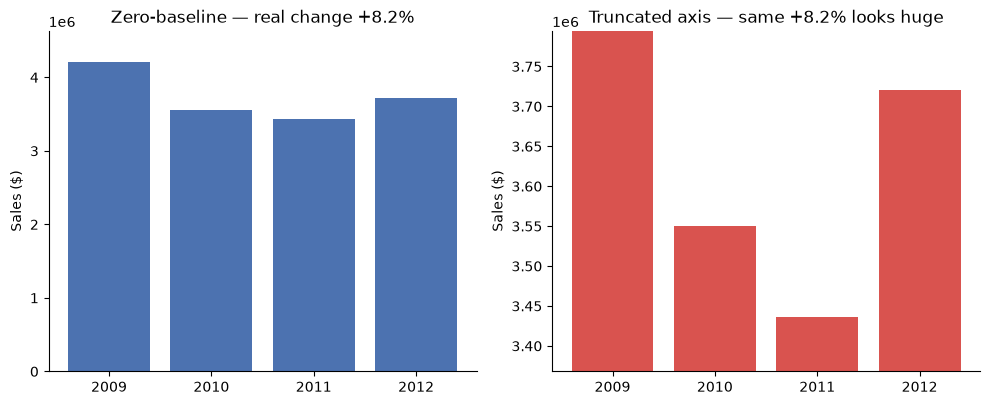

Real change from 2011 to 2012: +8.2%


In [6]:
yearly_sales = sales.groupby("Year")["Sales"].sum()

y1, y2 = yearly_sales.index[-2], yearly_sales.index[-1]
v1, v2 = yearly_sales.iloc[-2], yearly_sales.iloc[-1]
pct_change = (v2 - v1) / v1 * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

# Zero-baseline
axes[0].bar(yearly_sales.index.astype(str), yearly_sales.values, color="#4C72B0")
axes[0].set_ylim(0, yearly_sales.max() * 1.1)
axes[0].set_title(f"Zero-baseline — real change {pct_change:+.1f}%")
axes[0].set_ylabel("Sales ($)")

# Truncated
axes[1].bar(yearly_sales.index.astype(str), yearly_sales.values, color="#D9534F")
lo = min(v1, v2) * 0.98
hi = max(v1, v2) * 1.02
axes[1].set_ylim(lo, hi)
axes[1].set_title(f"Truncated axis — same {pct_change:+.1f}% looks huge")
axes[1].set_ylabel("Sales ($)")

plt.tight_layout()
plt.show()

print(f"Real change from {y1} to {y2}: {pct_change:+.1f}%")

**Reflection:**

_Your answer:_ The truncated-axis version — it visually amplifies a small percentage change into what looks like a crisis, so a reader glancing at the bars would badly misjudge the size of the move.

## Task 4 — Rewrite the Overreaching Annotation (Complaint #4)

**Real-world usage:** A colleague's annotation claimed a chart "PROVES" a strategy is
working — language the data alone cannot support.

**Why this technique:** Distinguishing descriptive / interpretive / persuasive
annotation lets you keep useful interpretation while cutting unsupported claims.

**TODO:**
1. Given the overreaching annotation text below, write a DESCRIPTIVE version (states
   only the fact) and an INTERPRETIVE version (explains a plausible, appropriately
   hedged reason) — no causal "PROVES" language in either.
2. Plot the yearly sales trend with your INTERPRETIVE annotation on the most recent
   data point.

ORIGINAL (persuasive, overreaching): This PROVES our new strategy is working -- scale it up immediately
DESCRIPTIVE: Sales in 2012 were +8.2% vs 2011.
INTERPRETIVE: 2012 sales rose +8.2% vs 2011; this is consistent with the new strategy contributing, though other factors may also be at play.


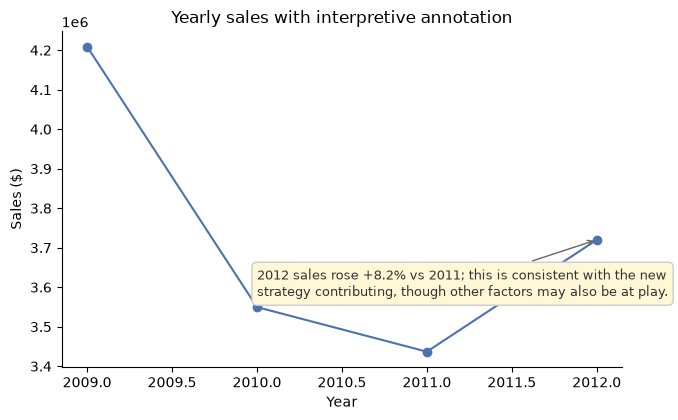

In [7]:
overreaching_original = "This PROVES our new strategy is working -- scale it up immediately"

descriptive_version = f"Sales in {y2} were {pct_change:+.1f}% vs {y1}."
interpretive_version = (f"{y2} sales rose {pct_change:+.1f}% vs {y1}; this is consistent with "
                        "the new strategy contributing, though other factors may also be at play.")

print("ORIGINAL (persuasive, overreaching):", overreaching_original)
print("DESCRIPTIVE:", descriptive_version)
print("INTERPRETIVE:", interpretive_version)

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0")
ax.set_xlabel("Year"); ax.set_ylabel("Sales ($)")
ax.set_title("Yearly sales with interpretive annotation")
ax.annotate(interpretive_version,
            xy=(yearly_sales.index[-1], yearly_sales.iloc[-1]),
            xytext=(yearly_sales.index[-3], yearly_sales.max() * 0.85),
            fontsize=9, color="#333",
            arrowprops=dict(arrowstyle="->", color="#666"),
            bbox=dict(boxstyle="round,pad=0.4", fc="#fff7d6", ec="#cccccc"),
            wrap=True)

plt.tight_layout()
plt.show()

**Reflection:**

_Your answer:_ A controlled comparison (e.g. an A/B rollout or a pre/post test with a control group) that rules out seasonality, price changes, and macro trends — a single-year uptick alone can't establish causation.

## Task 5 — The Decision (No Code)

_Your final recommendation:_ Ship the **axis-exaggeration fix (Task 3)** first — a misleading headline chart is the highest-blast-radius issue since executives will act on it. On the audit's *"is the visual encoding proportional to the underlying change?"* question, the truncated bar chart clearly fails. As a permanent guardrail, add a checklist step to the team's review process: every headline chart must be reviewed on both zero-baseline and truncated-axis versions before publishing, and any annotation using causal language ("proves", "because of") must cite a controlled comparison.